# Confronto tra Deep-LDA e LDA classica come collective variable per la metadinamica

Questo notebook confronta due varianti del metodo *Linear Discriminant Analysis* (LDA) implementate nel pacchetto [`mlcolvar`](https://mlcolvar.readthedocs.io/) [1] come collective variable (CV) per una simulazione di metadinamica ben temperata (WT-MetaD) del dipeptide di alanina:

- **Deep-LDA**: una rete neurale feed-forward apprende una mappa non lineare delle 45 distanze interatomiche tra atomi pesanti, sulla quale viene successivamente applicata la proiezione LDA che massimizza la separazione tra gli stati metastabili [2].
- **LDA classica (senza rete neurale)**: la proiezione di Fisher [3] viene applicata *direttamente* sui descrittori standardizzati, senza alcuna trasformazione non lineare intermedia.

L'obiettivo è mostrare, sia qualitativamente (mappe di Ramachandran colorate con isolinee di gradiente) sia quantitativamente (rapporto di Fisher, analisi delle transizioni), che la sola componente lineare non è in grado di separare correttamente i due stati metastabili nello spazio delle distanze interatomiche, e che questo si traduce in un biasing di metadinamica inefficace o addirittura fuorviante rispetto a quanto ottenuto con Deep-LDA.

Il notebook riutilizza i dati non biased (stati A e B) generati nella pipeline principale (`04_full.ipynb`), seguendo la metodologia della PLUMED Masterclass 22.05 [4].

**Riferimenti**

[1] Bonati, L. et al., *mlcolvar: A python library for machine learning collective variables for enhanced sampling*, J. Chem. Theory Comput. 2023.  
[2] Bonati, L.; Rizzi, V.; Parrinello, M. *Data-driven collective variables for enhanced sampling*. J. Phys. Chem. Lett. 2020, 11, 2998–3004.  
[3] Fisher, R. A. *The use of multiple measurements in taxonomic problems*. Ann. Eugen. 1936, 7, 179–188.  
[4] PLUMED Masterclass 22.05, *Data-driven collective variables and enhanced sampling*.


## 0. Setup

In [1]:
import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.core.stats import LDA as FisherLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
import mlcolvar.utils.plot
import plumed

In [2]:
# Configurazioni (identiche a 04_full.ipynb, cosi' da riutilizzare i dati gia' generati)
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data2"
GMX_CMD     = "gmx_mpi"  # GROMACS compilato con supporto MPI

os.chdir(BASE_DIR)
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [3]:
# helper functions (identiche a 04_full.ipynb)
import subprocess

def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output=True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

## 1. Caricamento del dataset di training

Riutilizziamo le due traiettorie non biased negli stati metastabili A e B generate nella Sezione 1.0 di `04_full.ipynb`, descritte tramite le 45 distanze interatomiche tra atomi pesanti (`d_*`).

In [4]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

filenames = [str(folderA / "COLVAR"), str(folderB / "COLVAR")]
n_states = len(filenames)

dataset, colvar = create_dataset_from_files(
    filenames,
    filter_args={'regex': 'd_'},   # solo le distanze tra atomi pesanti
    create_labels=True,
    return_dataframe=True,
)

n_input = dataset['data'].shape[-1]
datamodule = DictModule(dataset, lengths=[0.8, 0.2])

print(f"Numero di descrittori (distanze): {n_input}")
print(f"Numero totale di configurazioni:  {len(colvar)}")

Class 0 dataframe shape:  (5001, 53)
Class 1 dataframe shape:  (5001, 53)

 - Loaded dataframe (10002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (10002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15

## 2. Training di Deep-LDA

Architettura e iperparametri identici a quelli usati in `04_full.ipynb`, per garantire un confronto equo: una rete feed-forward `[n_input, 30, 30, 5]` con attivazione `tanh`, seguita dal blocco LDA che riduce lo spazio a 1 dimensione ($n_{\text{stati}}-1$).

In [5]:
torch.set_float32_matmul_precision('high')
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {accelerator.upper()}")

#------------- PARAMETRI (identici a 04_full.ipynb) -------------
nodes        = [n_input, 30, 30, 5]
activation   = 'tanh'

lrate        = 0.001
sw_reg       = 0.05
l2_reg       = 1e-5

num_epochs   = 500
es_patience  = 50
es_min_delta = 0.1
#------------------------------------------------------------------

nn_args = {'activation': activation}
options = {'nn': nn_args}

deeplda_model = DeepLDA(nodes, n_states=n_states, options=options)
deeplda_model.optimizer_name = "Adam"
deeplda_model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
deeplda_model.sw_reg = sw_reg

deeplda_model

Training on: GPU


DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

In [6]:
metrics_deep = MetricsCallback()
early_stopping_deep = EarlyStopping(monitor="valid_loss",
    min_delta=es_min_delta, patience=es_patience, mode="min")
tqdm_bar = TQDMProgressBar(refresh_rate=50)

trainer_deep = lightning.Trainer(
    callbacks=[metrics_deep, early_stopping_deep, tqdm_bar],
    max_epochs=num_epochs, logger=None, enable_checkpointing=False,
    accelerator=accelerator, enable_progress_bar=True, enable_model_summary=True)

trainer_deep.fit(deeplda_model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-15 08:59:58.653166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-15 08:59:59.632741: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-15 09:00:01.865472: I tensorflow/core/util/port.cc:153] oneDNN cust

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

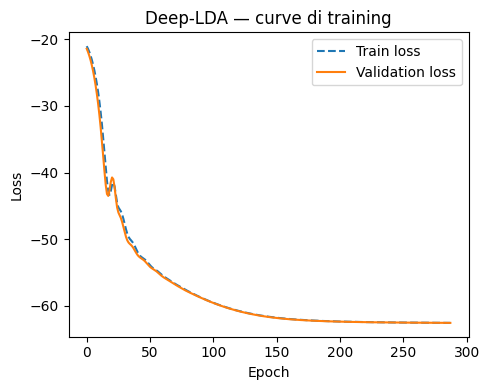

In [7]:
ax = plot_metrics(metrics_deep.metrics,
                  keys=['train_loss_epoch', 'valid_loss'],
                  linestyles=['--', '-'], yscale='linear')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Deep-LDA — curve di training")
ax.legend(["Train loss", "Validation loss"])
plt.tight_layout()

## 3. LDA classica (senza rete neurale)

In assenza del blocco di rete neurale, il metodo si riduce alla proiezione lineare di Fisher [3]: si cercano i coefficienti $\mathbf{w}$ che massimizzano il rapporto tra la dispersione *tra* le classi ($S_b$) e la dispersione *entro* le classi ($S_w$),

$$ \mathbf{w}^\star = \arg\max_{\mathbf{w}} \frac{\mathbf{w}^\top S_b \, \mathbf{w}}{\mathbf{w}^\top S_w \, \mathbf{w}} $$

risolto in forma chiusa tramite un problema agli autovalori generalizzato, senza alcuna ottimizzazione iterativa. `mlcolvar` implementa questo passaggio nella classe `mlcolvar.core.stats.LDA`, lo stesso blocco `lda` usato internamente da `DeepLDA` — con la differenza che qui viene applicato **direttamente ai descrittori standardizzati**, senza la mappa non lineare appresa dalla rete.

Poiché il confine tra gli stati metastabili del dipeptide di alanina non è, in generale, linearmente separabile nello spazio delle 45 distanze interatomiche, ci si attende che questa proiezione lineare sia significativamente meno efficace di Deep-LDA nel costruire una CV in grado di guidare correttamente il biasing di metadinamica.

In [9]:
from mlcolvar.core.stats.utils import cholesky_eigh

X = dataset['data']
y = dataset['labels'].long().view(-1)

# standardizzazione (equivalente al blocco norm_in usato internamente da DeepLDA)
mean = X.mean(0, keepdim=True)
std  = X.std(0, keepdim=True)
Xn   = (X - mean) / std

lda_model = FisherLDA(in_features=n_input, n_states=n_states)

# calcolo delle matrici di scatter, simmetrizzate esplicitamente per evitare
# errori numerici nel controllo di simmetria interno a mlcolvar (vedi nota sopra)
S_b, S_w = lda_model.compute_scatter_matrices(Xn, y, save_params=True)
S_b = 0.5 * (S_b + S_b.t())
S_w = 0.5 * (S_w + S_w.t())

evals, evecs = cholesky_eigh(S_b, S_w, lda_model.sw_reg, n_eig=lda_model.n_states - 1)
lda_model.evals, lda_model.evecs = evals, evecs

print(f"Autovalore di Fisher (LDA classica): {evals.item():.4f}")

Autovalore di Fisher (LDA classica): 54.4055


In [10]:
class LinearLDACV(torch.nn.Module):
    '''Wrapper TorchScript-esportabile per la proiezione LDA lineare
    (standardizzazione + proiezione di Fisher), analogo ai blocchi
    'norm_in' + 'lda' usati internamente da DeepLDA, ma senza il blocco 'nn'.'''
    def __init__(self, mean, std, evecs):
        super().__init__()
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)
        self.register_buffer('evecs', evecs)

    def forward(self, x):
        x = (x - self.mean) / self.std
        return torch.matmul(x, self.evecs)

lda_export_model = LinearLDACV(mean, std, evecs)
lda_export_model.eval()

with torch.no_grad():
    s_deep = deeplda_model(X).numpy().squeeze()
    s_lda  = lda_export_model(X).numpy().squeeze()

colvar['deeplda_cv'] = s_deep
colvar['lda_cv']     = s_lda

## 4. Confronto quantitativo: separazione degli stati

Come metrica di separazione confrontiamo il **rapporto di Fisher univariato**

$$ F = \frac{(\bar{s}_A - \bar{s}_B)^2}{\sigma_A^2 + \sigma_B^2} $$

calcolato sull'output scalare di ciascuna CV. Un valore di $F$ piu' alto indica una separazione piu' netta e una minore sovrapposizione tra le distribuzioni dei due stati.

In [11]:
def fisher_ratio(s, labels):
    s = np.asarray(s)
    labels = np.asarray(labels)
    sA, sB = s[labels == 0], s[labels == 1]
    return (sA.mean() - sB.mean())**2 / (sA.var() + sB.var())

F_deep = fisher_ratio(s_deep, colvar['labels'].values)
F_lda  = fisher_ratio(s_lda,  colvar['labels'].values)

print(f"Rapporto di Fisher — Deep-LDA:   {F_deep:.2f}")
print(f"Rapporto di Fisher — LDA lineare: {F_lda:.2f}")
print(f"Rapporto F_deep / F_lda:         {F_deep / F_lda:.2f}x")

Rapporto di Fisher — Deep-LDA:   11473.24
Rapporto di Fisher — LDA lineare: 108.93
Rapporto F_deep / F_lda:         105.33x


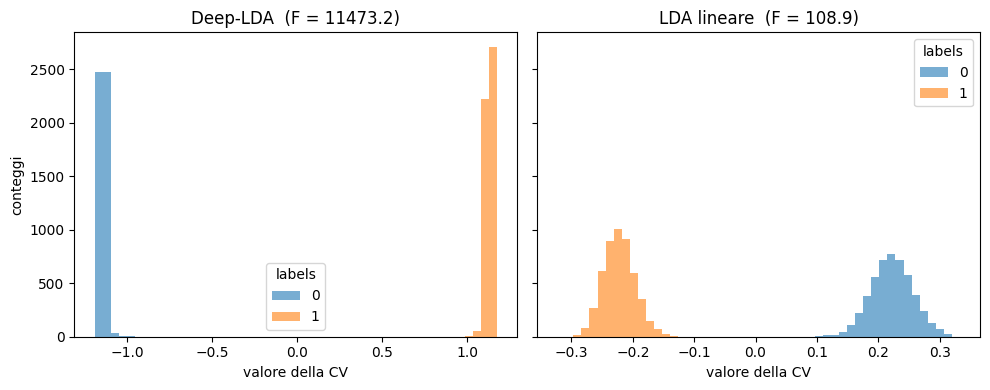

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=100, sharey=True)

for ax, cv_col, title, F in zip(axs, ['deeplda_cv', 'lda_cv'],
                                 ['Deep-LDA', 'LDA lineare'], [F_deep, F_lda]):
    colvar.pivot(columns='labels')[cv_col].plot.hist(bins=50, alpha=0.6, ax=ax, legend=True)
    ax.set_title(f'{title}  (F = {F:.1f})')
    ax.set_xlabel('valore della CV')

axs[0].set_ylabel('conteggi')
plt.tight_layout()

## 5. Mappa di Ramachandran con isolinee di gradiente

Per ciascuna CV mostriamo la mappa di Ramachandran ($\phi$, $\psi$) colorata in base al valore della CV, sovrapponendo le **isolinee** (linee di livello) del campo scalare interpolato: queste linee sono ortogonali al gradiente della CV e ne evidenziano la direzione e la regolarita' nello spazio delle coordinate fisiche. Una CV efficace mostra isolinee lisce, monotone e ben allineate lungo la coordinata di reazione fisica; una CV inefficace mostra invece isolinee irregolari, non monotone o disallineate rispetto al percorso di transizione.

In [13]:
def plot_ramachandran_gradient(phi, psi, cv, ax, cv_label='CV', levels=12, cmap='fessa'):
    '''Mappa di Ramachandran colorata dal valore della CV, con isolinee di gradiente
    ottenute per triangolazione (matplotlib.tri), utile quando i punti non sono
    distribuiti su una griglia regolare (es. traiettoria di MD).'''
    phi, psi, cv = np.asarray(phi), np.asarray(psi), np.asarray(cv)
    triang = tri.Triangulation(phi, psi)

    # superficie colorata (valore della CV)
    cf = ax.tricontourf(triang, cv, levels=levels, cmap=cmap)
    # isolinee di gradiente sovrapposte
    cl = ax.tricontour(triang, cv, levels=levels, colors='k', linewidths=0.6, alpha=0.7)
    ax.clabel(cl, inline=True, fontsize=6, fmt='%.1f')

    # punti campionati, per riferimento
    ax.plot(phi, psi, '.', ms=0.5, color='k', alpha=0.15)

    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label(cv_label)
    ax.set_xlabel(r'$\phi$ [rad]')
    ax.set_ylabel(r'$\psi$ [rad]')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    return cf, cl

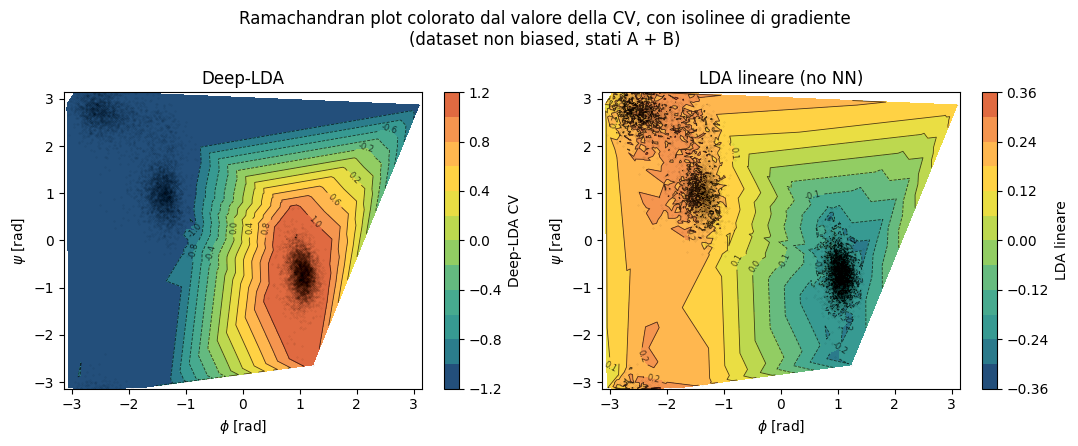

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), dpi=100)

plot_ramachandran_gradient(colvar['phi'], colvar['psi'], colvar['deeplda_cv'],
                            ax=axs[0], cv_label='Deep-LDA CV')
axs[0].set_title('Deep-LDA')

plot_ramachandran_gradient(colvar['phi'], colvar['psi'], colvar['lda_cv'],
                            ax=axs[1], cv_label='LDA lineare')
axs[1].set_title('LDA lineare (no NN)')

plt.suptitle('Ramachandran plot colorato dal valore della CV, con isolinee di gradiente\n(dataset non biased, stati A + B)')
plt.tight_layout()
plt.show()

# NOTA: le due traiettorie non biased esplorano soltanto l'intorno dei due minimi
# metastabili A e B, non la regione di transizione. Il confronto piu' informativo
# sulla capacita' di ciascuna CV di guidare correttamente il biasing si ottiene
# dopo aver eseguito le simulazioni di metadinamica (Sezioni 6-8).

## 6. Esportazione dei modelli in TorchScript

Entrambe le CV vengono esportate in formato TorchScript per essere utilizzate in PLUMED tramite la azione `PYTORCH_MODEL`, esattamente come nella pipeline Deep-LDA di `04_full.ipynb`. In questo modo l'unica differenza tra le due simulazioni di metadinamica sara' la CV impiegata, isolando l'effetto della componente non lineare.

In [15]:
# Deep-LDA -> 1_meta-deeplda/ (stessa cartella usata in 04_full.ipynb)
folder_deep = DATA_DIR / "90_1-meta-deeplda/"
Path(folder_deep).mkdir(parents=True, exist_ok=True)

deeplda_model.eval()
deeplda_model.to_torchscript(str(folder_deep / "model.ptc"), method="trace")

# LDA lineare -> 7_meta-lda/ (nuova cartella)
folder_lda = DATA_DIR / "90_2-meta-lda/"
Path(folder_lda).mkdir(parents=True, exist_ok=True)

traced_lda = torch.jit.trace(lda_export_model, X[:5])
torch.jit.save(traced_lda, str(folder_lda / "model.ptc"))

print(f"Deep-LDA model.ptc -> {folder_deep / 'model.ptc'}")
print(f"LDA lineare model.ptc -> {folder_lda / 'model.ptc'}")

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1549: `LightningModule.to_torchscript` has been deprecated in v2.7 and will be removed in v2.8. TorchScript is deprecated in PyTorch. Use `torch.export.export()` for model exporting instead. See https://pytorch.org/docs/stable/export.html for more information.


Deep-LDA model.ptc -> /home/dani/wslcoding/MCFM/ML-CV/data2/90_1-meta-deeplda/model.ptc
LDA lineare model.ptc -> /home/dani/wslcoding/MCFM/ML-CV/data2/90_2-meta-lda/model.ptc


## 7. Preparazione della metadinamica ben temperata con CV = LDA lineare

Costruiamo l'input PLUMED per la simulazione biased con la CV LDA lineare, mantenendo la stessa lista di descrittori e la stessa struttura dell'input usato per Deep-LDA. La `SIGMA` del kernel gaussiano viene stimata dalla deviazione standard della CV nel dataset non biased, seguendo la stessa buona pratica adottata in `04_full.ipynb`.

Se la simulazione con Deep-LDA (`1_meta-deeplda/`) non e' gia' stata eseguita, va lanciata anch'essa con lo stesso comando `mdrun`, cosi' da poter confrontare le due traiettorie biased nella Sezione 8.

In [16]:
ARG_LIST = "d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19"

STRIDE_ML = 100

sigma_lda = float(np.std(s_lda))
print(f"SIGMA stimata per la CV LDA lineare (std su dataset non biased): {sigma_lda:.4f}")

SIGMA stimata per la CV LDA lineare (std su dataset non biased): 0.2241


In [17]:
sigma_lda = 0.025

In [18]:
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_lda)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_lda)

with open(folder_lda / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute linear LDA CV (no neural network)
lda: PYTORCH_MODEL FILE=model.ptc    ARG={ARG_LIST}

metad: METAD ARG=lda.node-0 ...
   # Stessi parametri di deposito usati per Deep-LDA in 04_full.ipynb,
   # a parita' di condizioni di biasing
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.25 kJ/mol
   PACE=500 HEIGHT=1.25 BIASFACTOR=6.00
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.025 
   TEMP=300.0
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-2 GRID_MAX=2 GRID_BIN=750 CALC_RCT
...

# Print
PRINT FMT=%g STRIDE={STRIDE_ML} FILE=COLVAR ARG=lda.node-0,phi,psi,metad.*
ENDPLUMED
""")

print(f"Scritto: {folder_lda / 'plumed.dat'}")

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Scritto: /home/dani/wslcoding/MCFM/ML-CV/data2/90_2-meta-lda/plumed.dat


In [19]:
num_steps = 10_000_000  # 20 ns, stessa durata della simulazione Deep-LDA

# comando da lanciare nel terminale WSL2 (fuori da questo notebook)
print(f"cd {folder_lda}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data2/90_2-meta-lda
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


## 8. Analisi comparativa delle simulazioni biased

**Da eseguire dopo aver completato entrambe le simulazioni di metadinamica** (`1_meta-deeplda/` e `7_meta-lda/`). Confrontiamo:

1. l'evoluzione temporale della CV e il numero di transizioni reversibili tra gli stati A e B (un basso numero di transizioni indica che la metadinamica non sta esplorando efficacemente il paesaggio energetico);
2. la superficie di energia libera (FES) ricostruita per reweighting in funzione dell'angolo diedro $\phi$;
3. la mappa di Ramachandran con isolinee di gradiente calcolata sulla traiettoria biased, che mostra la regione di spazio effettivamente esplorata.

In [20]:
def augment_periodic(cv, weights=None, bandwidth=0.1):
    '''Aggiunge punti attraverso i bordi periodici (-pi, pi), come in 04_full.ipynb.'''
    mask = (cv < -np.pi + 3*bandwidth)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, index, cv[mask] + 2*np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    mask = (cv > np.pi - 5*bandwidth) & (cv < np.pi)
    index = np.argwhere(mask)[:, 0]
    cv = np.insert(cv, np.argwhere(mask)[:, 0], cv[mask] - 2*np.pi)
    if weights is not None:
        weights = np.insert(weights, index, weights[mask])

    return cv, weights


def count_transitions(cv, mean_A, mean_B):
    '''Conta il numero di transizioni reversibili tra gli stati A e B,
    classificando ogni frame in base alla soglia intermedia tra i due minimi.'''
    threshold = 0.5 * (mean_A + mean_B)
    state = np.where(cv < threshold, 0, 1) if mean_A < mean_B else np.where(cv > threshold, 0, 1)
    transitions = np.sum(np.abs(np.diff(state)))
    return transitions, state

In [22]:
kbT = 2.5

results = {}
for name, folder, cv_col in [("Deep-LDA", folder_deep, "deep.node-0"),
                              ("LDA lineare", folder_lda, "lda.node-0")]:
    colvar_path = folder / "COLVAR"
    if not colvar_path.exists():
        print(f"[{name}] COLVAR non trovato in {folder} — eseguire prima la simulazione (Sezione 7).")
        continue

    data = load_dataframe(str(colvar_path))
    mean_A = colvar.loc[colvar['labels'] == 0, 'deeplda_cv' if name == 'Deep-LDA' else 'lda_cv'].mean()
    mean_B = colvar.loc[colvar['labels'] == 1, 'deeplda_cv' if name == 'Deep-LDA' else 'lda_cv'].mean()

    n_trans, state = count_transitions(data[cv_col].values, mean_A, mean_B)
    results[name] = {"data": data, "n_transitions": n_trans}
    print(f"[{name}] transizioni A<->B osservate: {n_trans}")

[Deep-LDA] transizioni A<->B osservate: 15600
[LDA lineare] transizioni A<->B osservate: 2472


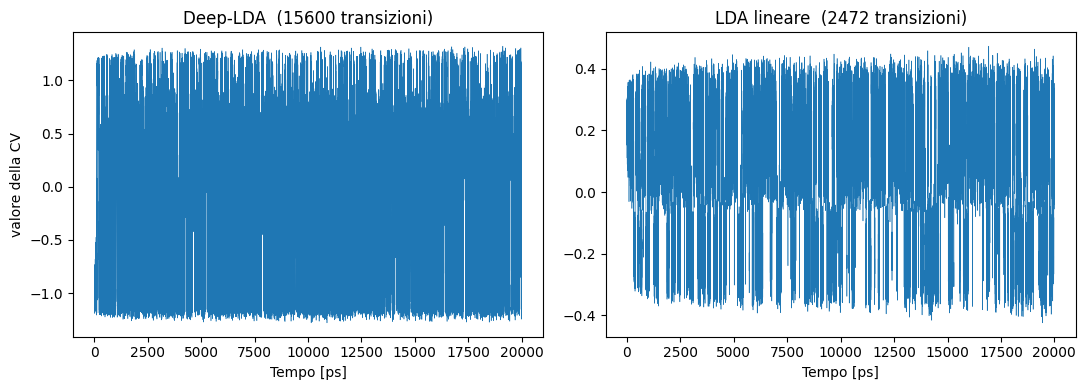

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), dpi=100, sharex=True)

for ax, (name, res) in zip(axs, results.items()):
    data = res["data"]
    cv_col = "deep.node-0" if name == "Deep-LDA" else "lda.node-0"
    ax.plot(data['time'], data[cv_col], lw=0.4)
    ax.set_title(f"{name}  ({res['n_transitions']} transizioni)")
    ax.set_xlabel('Tempo [ps]')

axs[0].set_ylabel('valore della CV')
plt.tight_layout()

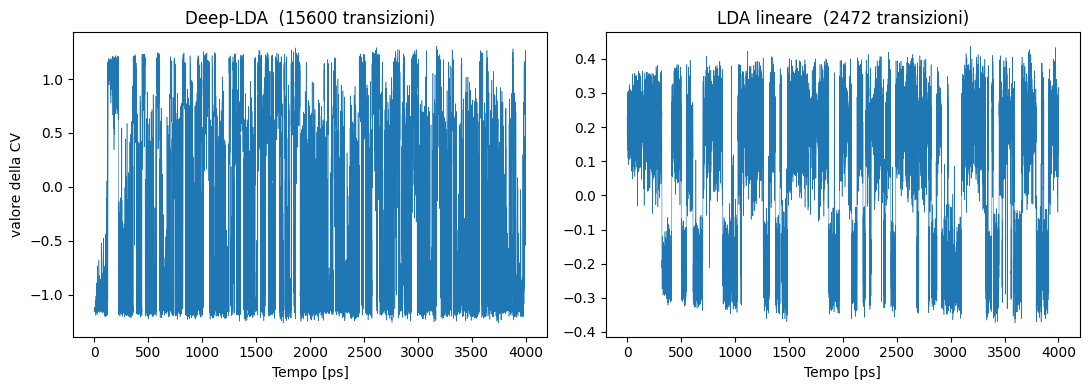

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), dpi=100, sharex=True)

for ax, (name, res) in zip(axs, results.items()):
    data = res["data"]
    cv_col = "deep.node-0" if name == "Deep-LDA" else "lda.node-0"
    ax.plot(data['time'][:20000:], data[cv_col][:20000:], lw=0.4)
    ax.set_title(f"{name}  ({res['n_transitions']} transizioni)")
    ax.set_xlabel('Tempo [ps]')

axs[0].set_ylabel('valore della CV')
plt.tight_layout()

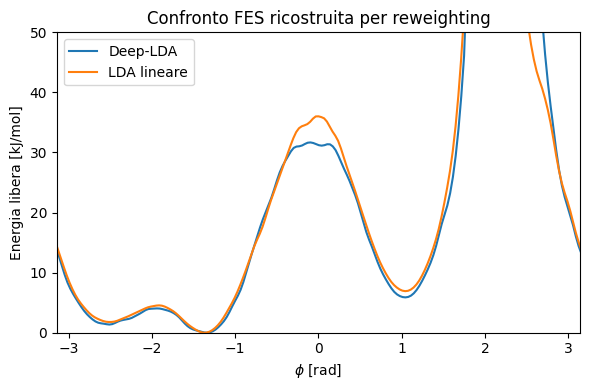

In [24]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)

for name, res in results.items():
    data = res["data"]
    w = np.exp(data['metad.bias'].values / kbT)
    phi = data['phi'].values

    phi_aug, w_aug = augment_periodic(phi, w, bandwidth=0.05)
    fes, grid, bounds, error = compute_fes(phi_aug, weights=w_aug, kbt=kbT,
                                            blocks=5, bandwidth=0.05, plot=False)
    ax.plot(grid, fes - np.min(fes), label=name)

ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('Energia libera [kJ/mol]')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, 50)
ax.legend()
ax.set_title('Confronto FES ricostruita per reweighting')
plt.tight_layout()

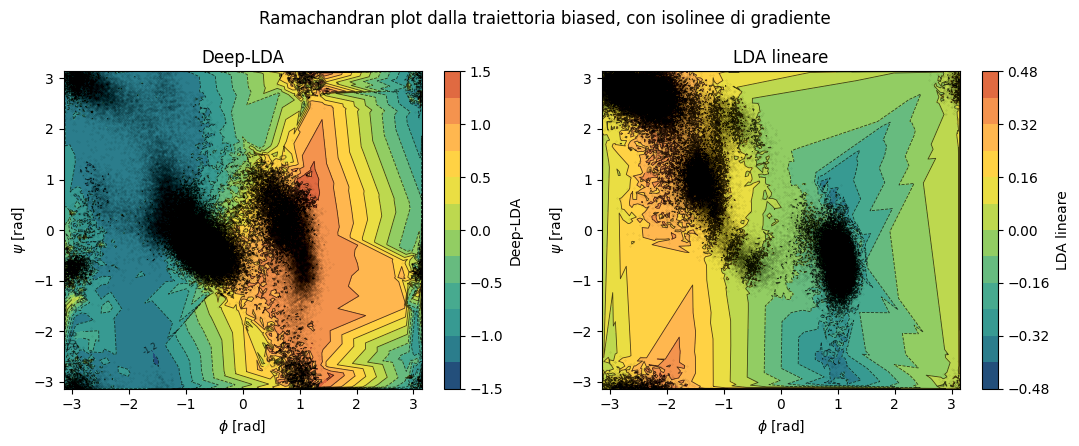

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), dpi=100)

for ax, (name, res) in zip(axs, results.items()):
    data = res["data"]
    cv_col = "deep.node-0" if name == "Deep-LDA" else "lda.node-0"
    plot_ramachandran_gradient(data['phi'], data['psi'], data[cv_col],
                                ax=ax, cv_label=name)
    ax.set_title(name)

plt.suptitle('Ramachandran plot dalla traiettoria biased, con isolinee di gradiente')
plt.tight_layout()
plt.show()

In [43]:
df_deep_lda = results['Deep-LDA']['data']
df_lda_lineare = results['LDA lineare']['data']

In [47]:
df_lda_lineare

,time,lda.node-0,phi,psi,metad.bias,metad.rbias,metad.rct,walker
0,0.00000,0.221020,-2.36867,2.64432,0.0000,0.00000,0.0000,0
1,0.20000,0.227093,-2.01898,2.09469,0.0000,0.00000,0.0000,0
2,0.40000,0.175650,-1.13140,2.51985,0.0000,0.00000,0.0000,0
3,0.60000,0.242515,-1.64722,2.11314,0.0000,0.00000,0.0000,0
4,0.80000,0.219681,-1.69175,2.11843,0.0000,0.00000,0.0000,0
...,...,...,...,...,...,...,...,...
99996,19999.20095,0.204236,-2.37208,2.42676,74.4251,2.90644,71.5186,0
99997,19999.40095,0.310165,-2.21736,3.09805,67.4673,-4.05133,71.5186,0
99998,19999.60095,0.070208,-2.93827,2.45515,59.0652,-12.45340,71.5186,0
99999,19999.80095,0.248247,-2.36799,2.84100,74.2224,2.70374,71.5186,0


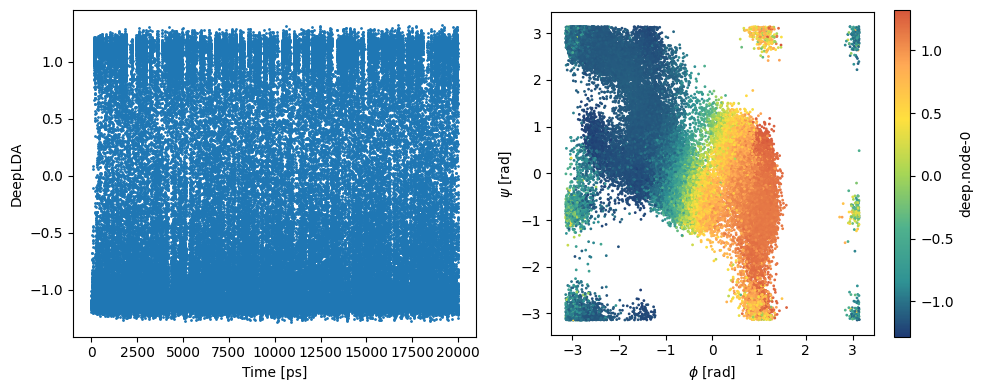

In [45]:
fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
df_deep_lda.plot.scatter('time','deep.node-0',s=1,ax=axs[0])
axs[0].set_xlabel('Time [ps]')
axs[0].set_ylabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
df_deep_lda.plot.scatter('phi','psi',c='deep.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

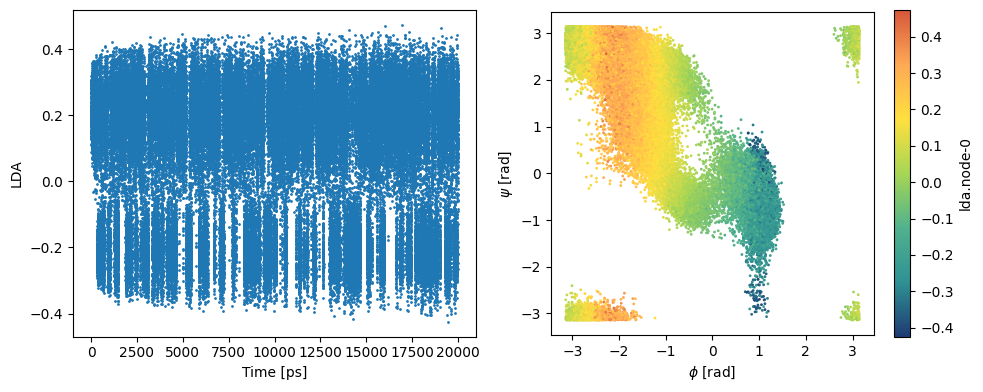

In [48]:
fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
df_lda_lineare.plot.scatter('time','lda.node-0',s=1,ax=axs[0])
axs[0].set_xlabel('Time [ps]')
axs[0].set_ylabel('LDA')
# 2D scatter plot colored with DeepLDA
df_lda_lineare.plot.scatter('phi','psi',c='lda.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## 9. Discussione

I tre confronti proposti (rapporto di Fisher, evoluzione temporale/numero di transizioni, FES ricostruita) permettono di quantificare in che misura la sola componente lineare della LDA sia sufficiente a costruire una CV efficace per il biasing.

Ci si attende che:

- il **rapporto di Fisher** della LDA lineare sia sensibilmente inferiore a quello di Deep-LDA, poiche' il confine tra gli stati A e B nello spazio delle 45 distanze interatomiche non e' in generale un iperpiano;
- la metadinamica guidata dalla **LDA lineare** mostri un numero di transizioni reversibili tra gli stati inferiore, ed esplori una regione della mappa di Ramachandran meno estesa o distorta rispetto a Deep-LDA, sintomo del fenomeno noto in letteratura come *hidden barrier problem*: una proiezione della coordinata di reazione su una CV che non cattura correttamente la topologia degli stati lascia barriere energetiche "nascoste" nelle direzioni ortogonali alla CV, che il biasing non e' in grado di superare efficacemente [5];
- la **FES ricostruita** lungo $\phi$ a partire dal run con LDA lineare possa risultare distorta o non convergente rispetto a quella ottenuta con Deep-LDA, a causa della limitata capacita' della proiezione lineare di guidare il sistema attraverso lo stato di transizione.

Questi risultati sono coerenti con l'argomentazione originale di Bonati, Rizzi e Parrinello [2], secondo cui l'introduzione di una rete neurale come mappa di feature non lineare, ottimizzata congiuntamente con l'obiettivo LDA, e' cruciale per costruire collective variable capaci di descrivere correttamente processi di riarrangiamento conformazionale non linearmente separabili nello spazio dei descrittori originali.

**Riferimenti aggiuntivi**

[5] Bussi, G.; Laio, A. *Using metadynamics to explore complicated free-energy landscapes*. Nat. Rev. Phys. 2020, 2, 200–212.
